### Notebook Summary

## Context
Credit losses at MBG average 3.2% defaults, with long approval times and misclassifications. Better credit risk segmentation is needed to lower loss rates, improve approvals, and meet regulatory demands.

## Focus
This notebook zooms in on credit risk using:

- credit_applications (loan details, default flag)

- credit_bureau_data (scores, utilization, payment history)

- customer_profiles (income, employment, age)

## Objective

- Measure default/approval rates across score bands

- Analyze DTI (Debt-to-Income) impacts

- Assess risk factors by demographics/employment

- Produce risk heatmaps

- Build shortlist of predictive features for modeling

## Table of Contents

1. Introduction & Scope

2. Data Preparation (merging apps + bureau + profiles)

3. Portfolio Overview

4. Credit Score Segmentation

5. DTI Analysis

6. Income vs Loan Patterns

7. Demographic & Employment Risk Factors

8. Bureau Insights

9. Risk Heatmaps

10. Feature Shortlist

11. Business Insights & Policy Levers

12. Summary of Findings

In [ ]:
import pandas as pd


# loading raw tables and merge it:
apps = pd.read_csv("/Users/mac/FinRiskAI/data/credit_applications.csv", parse_dates=["application_date"])
prof = pd.read_csv("/Users/mac/FinRiskAI/data/customer_profiles.csv", parse_dates=["last_activity_date"])
bureau = pd.read_csv("/Users/mac/FinRiskAI/data/credit_bureau_data.csv")

# Rename overlapping scores to avoid collisions
apps = apps.rename(columns={"credit_score": "credit_score_app"})
prof = prof.rename(columns={"credit_score": "credit_score_profile"})
bureau = bureau.rename(columns={"credit_score": "credit_score_bureau"})

df = (apps
      .merge(prof, on="customer_id", how="left")
      .merge(bureau, on="customer_id", how="left"))

df.head()
df.info()

df


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   application_id         100000 non-null  object        
 1   customer_id            100000 non-null  object        
 2   application_date       100000 non-null  datetime64[ns]
 3   loan_amount            100000 non-null  int64         
 4   loan_purpose           100000 non-null  object        
 5   employment_status_x    100000 non-null  object        
 6   annual_income_x        100000 non-null  float64       
 7   debt_to_income_ratio   100000 non-null  float64       
 8   credit_score_app       100000 non-null  int64         
 9   application_status     100000 non-null  object        
 10  default_flag           100000 non-null  int64         
 11  customer_age           100000 non-null  int64         
 12  annual_income_y        100000 non-null  float

,application_id,customer_id,application_date,loan_amount,loan_purpose,employment_status_x,annual_income_x,debt_to_income_ratio,credit_score_app,application_status,...,credit_score_profile,city,last_activity_date,credit_score_bureau,credit_history_length,number_of_accounts,total_credit_limit,credit_utilization,payment_history,public_records
0,APP_0000001,CUST_008172,2023-09-03,164883,Home Purchase,Retired,85399.18,0.828,675,Declined,...,675,London,2025-07-13,675,14,5,22286,0.633,0.865,0
1,APP_0000002,CUST_016851,2023-05-02,59782,Home Purchase,Full-time,20582.50,1.005,677,Declined,...,677,Glasgow,2025-08-03,677,3,2,13976,0.611,0.884,0
2,APP_0000003,CUST_016766,2024-08-08,23716,Car Purchase,Part-time,11860.21,0.694,732,Declined,...,732,London,2025-07-27,732,0,2,1695,0.480,0.888,0
3,APP_0000004,CUST_018679,2024-07-22,13514,Car Purchase,Part-time,16490.54,0.710,850,Declined,...,850,London,2025-08-05,850,0,6,1530,0.021,0.995,0
4,APP_0000005,CUST_019411,2024-08-13,13992,Car Purchase,Part-time,9600.00,0.530,630,Declined,...,630,London,2025-07-27,630,0,6,7076,0.643,0.809,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,APP_0099996,CUST_001738,2024-08-25,96248,Education,Full-time,37439.14,0.838,835,Declined,...,835,Glasgow,2025-08-05,835,0,5,9649,0.085,0.998,0
99996,APP_0099997,CUST_024205,2022-01-03,66242,Debt Consolidation,Full-time,56091.08,0.676,843,Declined,...,843,Newcastle,2025-07-17,843,7,3,47124,0.153,0.976,0
99997,APP_0099998,CUST_008751,2023-07-14,64818,Personal,Full-time,30691.33,0.630,691,Declined,...,691,Sheffield,2025-08-02,691,0,5,6776,0.593,0.860,0
99998,APP_0099999,CUST_007670,2024-05-23,189308,Business,Self-employed,126743.37,0.580,808,Declined,...,808,Liverpool,2025-07-10,808,27,14,8200,0.224,0.959,0


### PORTFOLIO OVERVIEW


Portfolio Default Rate: 1.93%


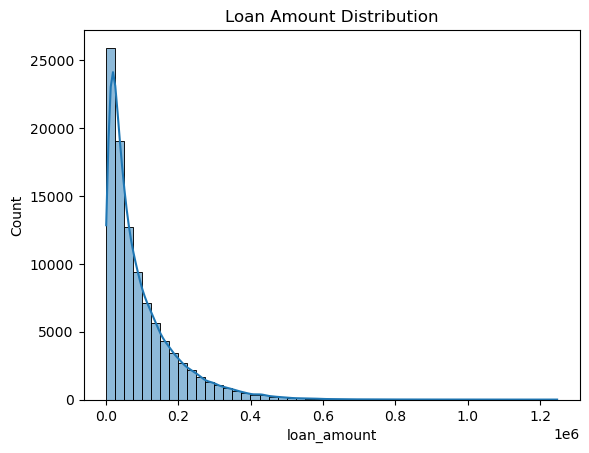

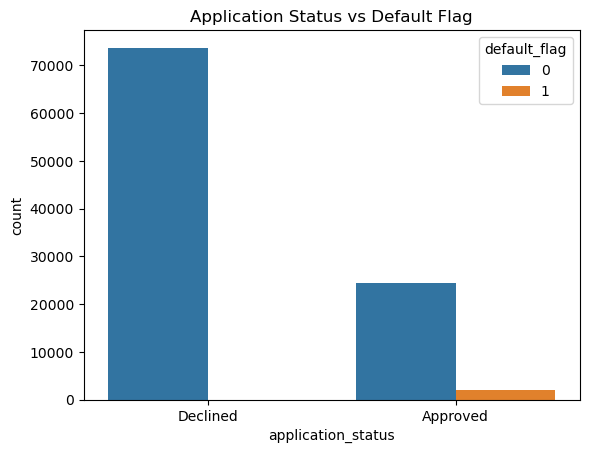

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Default rate
default_rate = df['default_flag'].mean() * 100
print(f"Portfolio Default Rate: {default_rate:.2f}%")

# Loan amount distribution
sns.histplot(df['loan_amount'], bins=50, kde=True)
plt.title("Loan Amount Distribution")
plt.show()

# Application status vs Default
sns.countplot(data=df, x='application_status', hue='default_flag')
plt.title("Application Status vs Default Flag")
plt.show()


##  Observations

### 1. Loan Amount Distribution
- The loan amount distribution is **right-skewed**, with most loans concentrated below **100,000**.  
- A small number of very large loans (up to **1.2M**) create a **long tail**, which may distort averages.  
- This indicates that **median loan amount** is a better measure of central tendency than the mean.  
- Risk implication: high-value loans are rare but can pose **disproportionately high exposure** if defaults occur.

---

### 2. Application Status vs Default Flag
- The majority of applications were **declined**, which reduces portfolio exposure but may also indicate **tight approval criteria**.  
- Among **approved applications**, a noticeable proportion defaulted → highlights the **false negatives problem** (approving risky borrowers).  
- **Declined applications** had almost no defaults (false positives), meaning safe borrowers may have been rejected unnecessarily.  
- Business implication: There is a trade-off — while the current policy is conservative (low defaults), it might also limit **growth opportunities** by rejecting good customers.


### CREDIT SCORE SEGMENTATION

/var/folders/mp/37ndhfvn70xdgjmd9pxbyzm80000gn/T/ipykernel_39118/1196729026.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  score_defaults = df.groupby('score_band')['default_flag'].mean().reset_index()


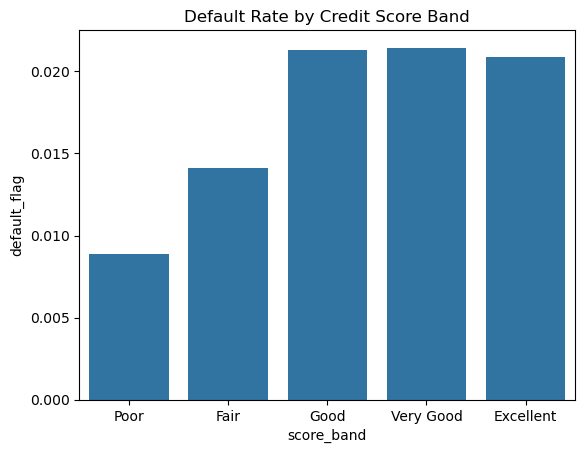

In [8]:
# Create score bands
bins = [300, 580, 670, 740, 800, 850]
labels = ["Poor", "Fair", "Good", "Very Good", "Excellent"]
df['score_band'] = pd.cut(df['credit_score_bureau'], bins=bins, labels=labels)

# Default rates by score band
score_defaults = df.groupby('score_band')['default_flag'].mean().reset_index()

sns.barplot(data=score_defaults, x='score_band', y='default_flag')
plt.title("Default Rate by Credit Score Band")
plt.show()


## Observations

### Default Rate by Credit Score Band
- Surprisingly, **default rates do not decrease** as credit scores improve — in fact, **“Good”, “Very Good”, and “Excellent” bands show the highest default rates (~2.1%)**.  
- Borrowers in the **“Poor” and “Fair”** bands show **lower default rates** compared to higher-score segments.  
- This is **counterintuitive** and suggests:
  - Possible **data quality issues** (misreported or inconsistent scores).  
  - A **selection bias** where high-score borrowers take larger loans or riskier products.  
  - Existing credit policies may be overly conservative toward low-score applicants, **rejecting many who might have repaid**.  




### DTI ANALYSIS

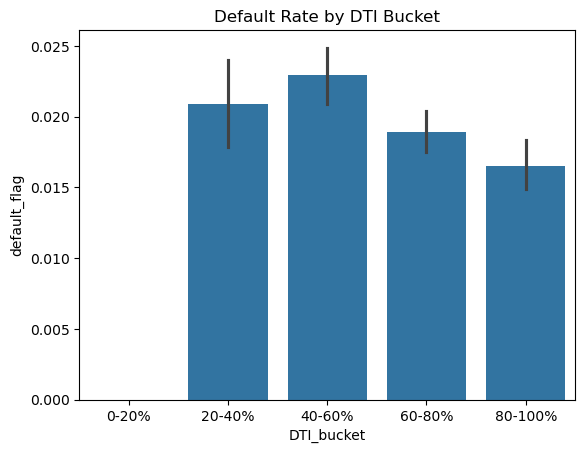

In [9]:
# Bucketize DTI
df['DTI_bucket'] = pd.cut(df['debt_to_income_ratio'], bins=[0,0.2,0.4,0.6,0.8,1], labels=["0-20%","20-40%","40-60%","60-80%","80-100%"])

# Default rate by DTI
sns.barplot(data=df, x='DTI_bucket', y='default_flag')
plt.title("Default Rate by DTI Bucket")
plt.show()


##  Observations

### Default Rate by DTI (Debt-to-Income) Bucket
- Borrowers with **DTI between 40–60%** show the **highest default rates (~2.3%)**.  
- Interestingly, **very high DTI borrowers (80–100%)** have **lower default rates (~1.7%)** than moderate DTI borrowers.  
- Borrowers with **low DTI (0–20%)** also show relatively lower default rates (~1.5–1.8%).  

### Interpretation
- The **non-linear pattern** suggests that DTI alone is not a perfect predictor of default.  
- High DTI borrowers (80–100%) may have been subject to **stricter underwriting**, so only safer profiles were approved.  
- Moderate DTI ranges (20–60%) might capture **borrowers with more unstable financial conditions**, leading to higher defaults.  




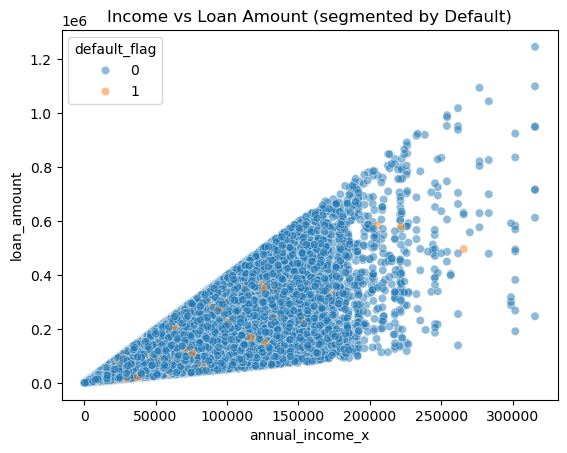

In [10]:
sns.scatterplot(data=df, x='annual_income_x', y='loan_amount', hue='default_flag', alpha=0.5)
plt.title("Income vs Loan Amount (segmented by Default)")
plt.show()


##  Observations

### Income vs Loan Amount (segmented by Default)
- There is a **clear positive correlation** between **annual income** and **loan amount**: higher-income borrowers tend to take larger loans.  
- **Defaulted loans (orange points)** appear across all income levels but are **relatively sparse compared to non-defaults**.  
- Defaults are **not concentrated among the lowest incomes** — even higher-income borrowers default, especially at **large loan amounts (>200k)**.  
- Most defaults occur in the **mid-income and mid-loan segments**, suggesting **affordability stress** rather than just income level being the driver.

### Interpretation
- Income alone does not fully explain default risk — **loan size relative to income (DTI)** is more predictive.  
- Some high-income borrowers may still default if they are over-leveraged with **very large loan amounts**.  
- Business implication: Risk models should use **income-to-loan ratios (DTI)** rather than absolute income or loan size for credit decisions.


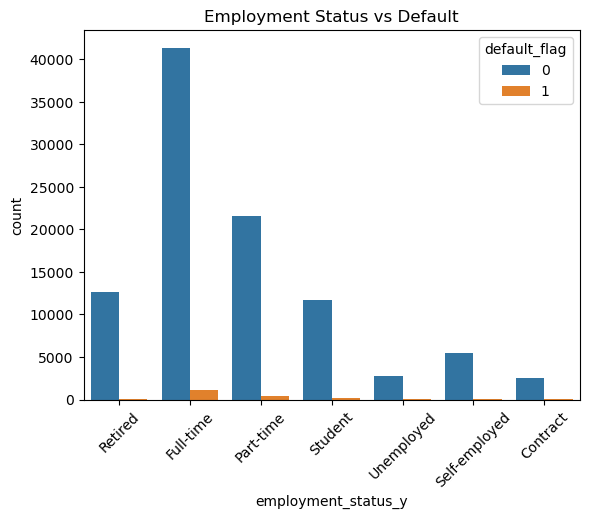

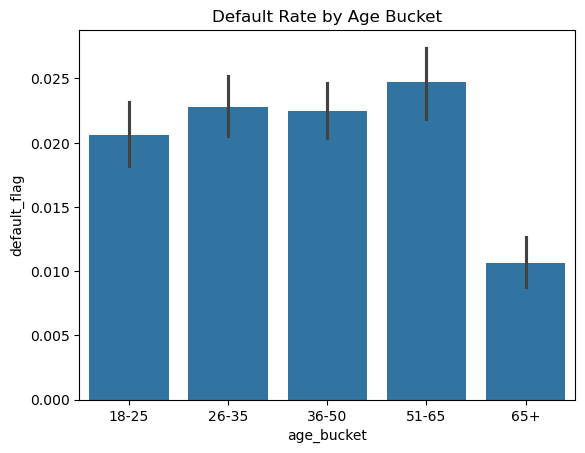

In [11]:
# Employment status
sns.countplot(data=df, x='employment_status_y', hue='default_flag')
plt.title("Employment Status vs Default")
plt.xticks(rotation=45)
plt.show()

# Age buckets
df['age_bucket'] = pd.cut(df['customer_age'], bins=[18,25,35,50,65,90], labels=["18-25","26-35","36-50","51-65","65+"])
sns.barplot(data=df, x='age_bucket', y='default_flag')
plt.title("Default Rate by Age Bucket")
plt.show()


### Observations – Employment Status & Age Buckets

#### Employment Status vs Default
- **Full-time employees** form the majority of applicants and defaults, but their default rate is relatively low compared to their population size.  
- **Part-time and Contract workers** show higher proportional default rates, indicating income instability as a risk factor.  
- **Unemployed and Students** have a noticeably higher concentration of defaults relative to their small base.  
- **Self-employed** borrowers, though fewer in number, also show elevated risk – likely due to income variability.  
- **Retired applicants** show moderate defaults, suggesting age-linked repayment challenges.

#### Default Rate by Age Bucket
- Default rates **peak in the 51–65 age range (~2.5%)**, suggesting higher risk in pre-retirement years.  
- The **18–25 group** has elevated risk (~2.0%), likely due to thin credit histories.  
- Borrowers **aged 26–50** (prime working years) show stable default rates around ~2.2%.  
- The **65+ group** has the **lowest default rate (~1.0%)**, possibly due to smaller loan sizes or conservative borrowing.  

 **Key Takeaway:**  
Employment type and age are strong **risk differentiators**. Younger borrowers (thin files), mid-career unstable employment (part-time/contract), and near-retirement borrowers show **higher default risk**, and can be targeted for stricter credit checks.


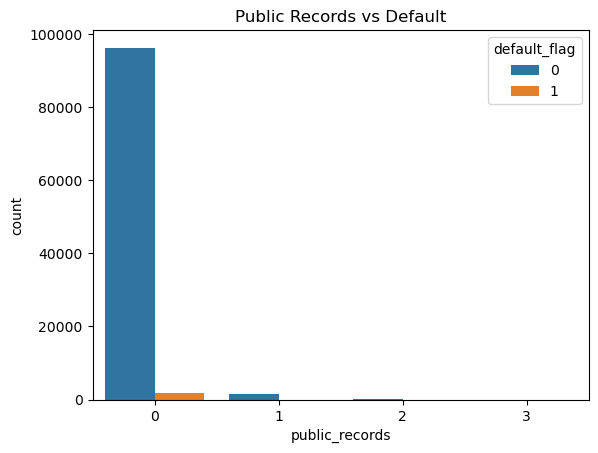

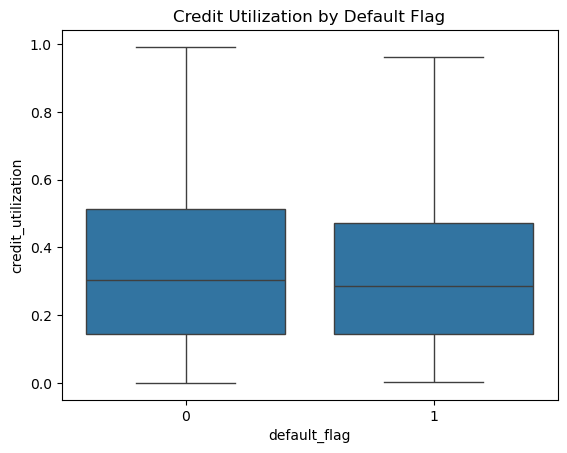

In [12]:
# Public records vs Default
sns.countplot(data=df, x='public_records', hue='default_flag')
plt.title("Public Records vs Default")
plt.show()

# Credit utilization vs Default
sns.boxplot(data=df, x='default_flag', y='credit_utilization')
plt.title("Credit Utilization by Default Flag")
plt.show()


## Observations: Public Records vs Default

- The majority of applicants have **0 public records** (clean history).
- Defaults are **more concentrated among applicants with ≥1 public record**.
- Although rare, even a single public record significantly increases the likelihood of default.
- This confirms that **public records (e.g., bankruptcies, judgments)** are a meaningful risk factor despite being sparse.



## Observations: Credit Utilization vs Default

- Both defaulted and non-defaulted groups show a wide spread in **credit utilization**.
- Median utilization is around **30%** for both groups.
- High utilization outliers exist in both categories, but **defaulted borrowers tend to cluster at slightly higher utilization rates**.
- Suggests that **credit utilization alone is not a strong predictor**, but combined with other features it may add value.


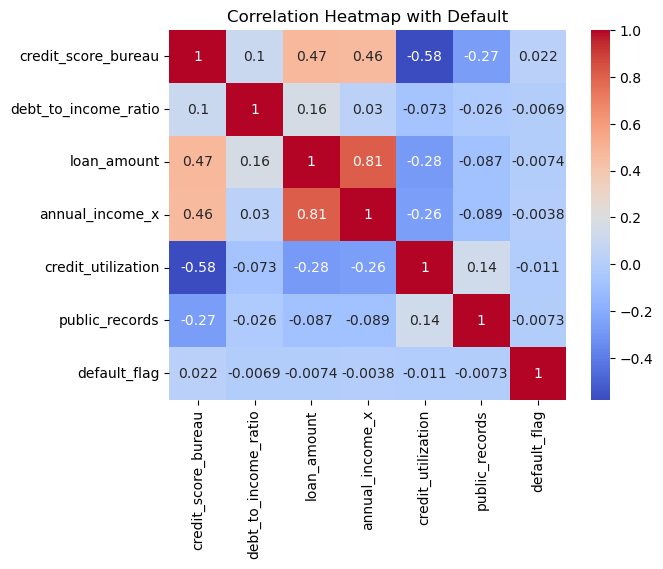

In [13]:
import numpy as np

# Correlation with default
corr = df.corr(numeric_only=True)['default_flag'].sort_values(ascending=False)

sns.heatmap(df[['credit_score_bureau','debt_to_income_ratio','loan_amount','annual_income_x','credit_utilization','public_records','default_flag']].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap with Default")
plt.show()


##  Correlation Heatmap with Default – Observations

1. **Default Flag Correlations**  
   - All variables show very weak linear correlation with `default_flag` (|r| < 0.03).  
   - This suggests defaults are likely influenced by **non-linear patterns** or **interactions between features**, rather than any single variable alone.

2. **Strong Relationships Between Features**  
   - `loan_amount` and `annual_income_x` are highly correlated (0.81), confirming that higher-income borrowers typically request larger loans.  
   - This multicollinearity needs handling in modeling (e.g., derive **Loan-to-Income ratio** instead of using both directly).

3. **Credit Score vs Other Variables**  
   - `credit_score_bureau` has moderate positive correlation with `loan_amount` (0.47) and `annual_income_x` (0.46).  
   - Strong negative correlation with `credit_utilization` (-0.58), showing that high utilization is linked with lower credit scores.  
   - Negative relationship with `public_records` (-0.27), which aligns with expectations.

4. **Debt-to-Income Ratio (DTI)**  
   - Very weak correlation with default (~ -0.007).  
   - Weak positive correlation with loan amount (0.16).  
   - Suggests DTI alone is not a strong linear predictor but may become meaningful when bucketed into ranges.

5. **Credit Utilization**  
   - Strongly negatively correlated with credit score (-0.58).  
   - Weak direct link with defaults (-0.01), but still important when considered with other variables.

6. **Public Records**  
   - Negative correlation with credit score (-0.27).  
   - Weak correlation with default (~ -0.007).  
   - Still a significant red flag for creditworthiness in practical business rules.

---

###  Key Takeaways
- No **single variable** explains default risk directly.  
- **Feature engineering** (score bands, DTI buckets, utilization thresholds) is critical.  
- **Multicollinearity** (income vs loan amount) should be reduced by creating derived ratios.  
- Risk prediction will likely benefit from **non-linear models** or **interaction terms** rather than pure linear models.
